# TASOPT-lite: a reduced-order aircraft sizing notebook

This notebook is a runnable companion to **[Weight, Drag, Thrust, Range](https://claude.ai/code/artifact/d4bac5f7-de63-4425-98d8-02f3943b250f)**,
a pedagogical walkthrough of Mark Drela's *TASOPT 2.00: Transport Aircraft
System OPTimization, Technical Description* (MIT, 2010) — the physics-based
sizing methodology behind the open-source Julia code
[MIT-LAE/TASOPT.jl](https://github.com/MIT-LAE/TASOPT.jl).

It re-implements the *shape* of TASOPT's method in ~250 lines of plain Python:
a fuselage sized as a pressure vessel, a wing sized as a cantilever beam, a
turbofan modeled as an ideal Brayton cycle, a Breguet-style mission, and the
outer fixed-point loop that ties them together to converge on a maximum
take-off mass (MTOM). It is **not** TASOPT — real TASOPT integrates spanwise
structural loads, station-by-station engine thermodynamics with real gas
properties, an XFOIL-derived transonic airfoil database, and a multi-segment
mission profile, all inside a full multidisciplinary Newton solve. This
notebook keeps the same *loop*, with every sub-model replaced by the
simplest closed-form relation that still points in the right direction —
so you can read every line, run it in seconds, and watch the fixed point
emerge.

| Sub-model | Full TASOPT | This notebook |
|---|---|---|
| Gas thermodynamics | Thermally perfect gas, `cp(T)` from curve fits | Calorically perfect gas, constant `cp` per stream |
| Engine operation | Design + off-design point via 8×8 Newton solve on compressor/fan maps | Single on-design ideal Brayton cycle, no maps |
| Wing/fuselage drag | Transonic airfoil CFD database, shock-unsweep, spanwise strip theory | Flat-plate skin friction × form factor + a fixed-`e` induced term |
| Structural sizing | Spanwise-integrated bending/shear/torsion, material stacking | Root-bending-moment sparcap sizing with lumped weight fractions |
| Mission integration | Multi-segment climb/cruise-climb/descent integrated in time | Fixed segment weight fractions + one closed-form Breguet cruise leg |

Every number this notebook produces should be read as "the right order of
magnitude, for the right reasons" — not a certified weight statement.

## 1. Constants and the ISA atmosphere

Everything downstream needs temperature, pressure, density and the speed of
sound as a function of altitude, plus viscosity for the skin-friction drag
later on. This is the standard two-layer International Standard Atmosphere
(troposphere + the first stretch of the isothermal stratosphere), and
Sutherland's law for viscosity.

In [1]:
import numpy as np

g       = 9.80665
R_air   = 287.05
gamma_c = 1.40
gamma_h = 1.33
cp_c    = gamma_c * R_air / (gamma_c - 1.0)     # ~1004.7 J/kg-K, cold-side air
R_h     = 287.0
cp_h    = gamma_h * R_h / (gamma_h - 1.0)       # ~1156.7 J/kg-K, hot combustion gas
h_fuel  = 43.0e6                                 # J/kg, jet fuel LHV


def isa(h_m):
    # Standard atmosphere: returns (T [K], p [Pa], rho [kg/m^3], a [m/s]).
    T0, p0, lapse = 288.15, 101325.0, 0.0065
    if h_m <= 11000.0:
        T = T0 - lapse * h_m
        p = p0 * (T / T0) ** (g / (lapse * R_air))
    else:
        T11 = T0 - lapse * 11000.0
        p11 = p0 * (T11 / T0) ** (g / (lapse * R_air))
        T = T11
        p = p11 * np.exp(-g * (h_m - 11000.0) / (R_air * T11))
    rho = p / (R_air * T)
    a = np.sqrt(gamma_c * R_air * T)
    return T, p, rho, a


def sutherland_mu(T):
    return 1.458e-6 * T ** 1.5 / (T + 110.4)


T, p, rho, a = isa(11000.0)
print(f"At 11 km: T={T:.1f} K   p={p/1000:.1f} kPa   rho={rho:.3f} kg/m^3   a={a:.1f} m/s")

At 11 km: T=216.6 K   p=22.6 kPa   rho=0.364 kg/m^3   a=295.1 m/s


## 2. Aircraft definition

A baseline sized like a **Boeing 737-800**: a twin-aisle-free, single-aisle
narrowbody with a double-bubble-free (single) circular fuselage, an
aspect-ratio-9.45 swept wing, and two ~120 kN-class high-bypass turbofans.
These four dataclasses are the *only* place geometry, mission, engine and
material choices live — everything below is a function of them.

In [2]:
from dataclasses import dataclass

@dataclass
class Geometry:
    R_fuse: float = 1.955       # fuselage radius, m
    l_fuse: float = 39.5        # overall fuselage length, m
    l_cabin: float = 29.0       # cabin length, m
    AR: float = 9.45            # wing aspect ratio
    sweep_deg: float = 25.0     # quarter-chord sweep
    tc: float = 0.12            # wing thickness-to-chord
    taper: float = 0.24         # wing taper ratio
    Sh_frac: float = 0.28       # horizontal tail area / wing area
    Sv_frac: float = 0.20       # vertical tail area / wing area

@dataclass
class MissionSpec:
    n_pax: int = 162
    mass_per_pax: float = 102.0     # kg, passenger + bag
    range_target_km: float = 5000.0
    cruise_mach: float = 0.785
    cruise_alt_m: float = 11000.0
    reserve_frac: float = 0.06
    CL_cruise: float = 0.55

@dataclass
class EngineSpec:
    n_eng: int = 2
    BPR: float = 5.1       # bypass ratio
    OPR: float = 32.0      # overall pressure ratio
    T4: float = 1450.0     # turbine inlet ("combustor exit") temperature, K
    pi_f: float = 1.70     # fan pressure ratio
    pi_d: float = 0.99     # inlet recovery
    pi_b: float = 0.96     # burner pressure ratio
    eta_f: float = 0.90    # fan polytropic-ish efficiency
    eta_c: float = 0.87    # compressor efficiency
    eta_t: float = 0.90    # turbine efficiency
    eta_b: float = 0.99    # combustor efficiency
    eta_n: float = 0.98    # nozzle efficiency
    cruise_thrust_lapse: float = 0.22   # cruise thrust / sea-level-static thrust

@dataclass
class Materials:
    rho_al: float = 2700.0        # kg/m^3, 2024-T3 aluminum
    sigma_skin: float = 103.0e6   # Pa, working hoop stress
    sigma_cap: float = 262.0e6    # Pa, working sparcap stress
    delta_p: float = 57.0e3       # Pa, cabin pressure differential
    f_string: float = 0.35        # stringers, fraction of skin mass
    f_frame: float = 0.25         # frames
    f_fadd: float = 0.20          # doors/joints/fittings
    f_bend: float = 0.10          # fuselage bending allowance
    N_ult: float = 3.75           # ultimate load factor

geom    = Geometry()
mission = MissionSpec()
eng     = EngineSpec()
mats    = Materials()
m_pay   = mission.n_pax * mission.mass_per_pax
print(f"Design payload: {m_pay:,.0f} kg  ({mission.n_pax} pax at {mission.mass_per_pax:.0f} kg each)")

Design payload: 16,524 kg  (162 pax at 102 kg each)


## 3. Fuselage: a pressurized beam

TASOPT sizes fuselage skin thickness from hoop stress in the pressurized
shell (Section A.2 of the technical description), then adds stringers,
frames, floor, insulation, windows, and door/joint fittings as weight
*fractions* of that skin — the "build-up" method every conceptual-design
textbook uses, just derived from a real pressure-vessel calculation instead
of a regression fit.

$$t_\text{skin} = \dfrac{\Delta p \cdot R_\text{fuse}}{\sigma_\text{skin}}$$

This notebook keeps the pressure-vessel skin-thickness calculation exactly
as TASOPT derives it, but replaces TASOPT's spanwise-integrated bending-load
model (which needs the fuselage's full weight *distribution* — payload,
fuel, engines — to compute a bending moment at every station) with a flat
10% "bending allowance" fraction on top of the pressure shell.

In [3]:
def fuselage_mass(geom: Geometry, mats: Materials, m_pay: float):
    t_skin = mats.delta_p * geom.R_fuse / mats.sigma_skin                 # pressure-vessel hoop stress
    A_skin = 2 * np.pi * geom.R_fuse * t_skin
    m_skin = mats.rho_al * A_skin * geom.l_fuse * (1 + mats.f_string + mats.f_frame + mats.f_fadd)
    m_shell = m_skin * (1 + mats.f_bend)
    m_tailcone = 0.05 * m_shell

    floor_areal = 9.0           # kg/m^2, structure + planking
    m_floor = floor_areal * (2 * geom.R_fuse * geom.l_cabin)

    window_perlen = 3.5         # kg/m
    insul_areal = 0.9           # kg/m^2
    m_window = window_perlen * geom.l_cabin
    m_insul = insul_areal * (2 * np.pi * geom.R_fuse * geom.l_cabin * 1.1)

    f_apu, f_seat, f_padd = 0.04, 0.10, 0.34      # fractions of payload
    m_apu  = f_apu  * m_pay
    m_seat = f_seat * m_pay
    m_padd = f_padd * m_pay
    m_fix  = 500.0               # fixed avionics/cockpit/crew weight

    m_total = (m_shell + m_tailcone + m_floor + m_window + m_insul
               + m_apu + m_seat + m_padd + m_fix)
    detail = dict(t_skin_mm=t_skin * 1e3, m_shell=m_shell, m_floor=m_floor,
                  m_window=m_window, m_insul=m_insul, m_apu=m_apu,
                  m_seat=m_seat, m_padd=m_padd, m_fix=m_fix, m_tailcone=m_tailcone)
    return m_total, detail


m_fuse_test, detail = fuselage_mass(geom, mats, m_pay)
print(f"Fuselage mass: {m_fuse_test:,.0f} kg   (skin t = {detail['t_skin_mm']:.2f} mm)")
for k, v in detail.items():
    if k != "t_skin_mm":
        print(f"   {k:12s} {v:8,.0f} kg")

Fuselage mass: 12,853 kg   (skin t = 1.08 mm)
   m_shell         2,806 kg
   m_floor         1,021 kg
   m_window          102 kg
   m_insul           353 kg
   m_apu             661 kg
   m_seat          1,652 kg
   m_padd          5,618 kg
   m_fix             500 kg
   m_tailcone        140 kg


## 4. Wing and tail: cantilever beams

TASOPT integrates the spanwise bending moment from an elliptic-ish lift
distribution out to the tip, then sizes a sparcap at *every* span station
(Section A.5-A.6). The essential physics collapses to one number: the
**root bending moment**, which for an elliptically loaded cantilever of
span $b$ carrying the aircraft's weight is $M_\text{root} \propto N_\text{ult}\, W\, b$.
Sizing a cap of chord-fraction depth $h_\text{box}=t/c \cdot c_\text{root}$
against that moment gives the sparcap area directly; everything else
(shear webs, ribs, secondary structure) is carried as weight fractions on
top, exactly as TASOPT's own build-up does.

In [4]:
f_web, f_rib, f_secondary = 0.25, 0.15, 0.28

def wing_mass(geom: Geometry, mats: Materials, MTOM: float, S: float):
    b = np.sqrt(geom.AR * S)
    lam = geom.taper
    c_root = 2 * S / (b * (1 + lam))
    M_root = mats.N_ult * MTOM * g * b / (3 * np.pi)     # elliptic-load root bending moment, per half-wing
    h_box = geom.tc * c_root
    A_cap = M_root / (mats.sigma_cap * h_box)
    k_avg = 0.45      # span-average factor standing in for TASOPT's full spanwise integral
    m_sparcap = 2 * mats.rho_al * A_cap * (b / 2) * k_avg
    m_wingbox = m_sparcap * (1 + f_web + f_rib)
    m_wing = m_wingbox * (1 + f_secondary)
    return m_wing, b, c_root


def tail_mass(geom: Geometry, S: float):
    S_h = geom.Sh_frac * S
    S_v = geom.Sv_frac * S
    k_tail = 22.0     # kg/m^2, representative areal weight for a lightly loaded tail surface
    return k_tail * S_h, k_tail * S_v


m_wing_test, b_test, c_root_test = wing_mass(geom, mats, 72000.0, 125.0)
m_h, m_v = tail_mass(geom, 125.0)
print(f"Wing mass: {m_wing_test:,.0f} kg   span b = {b_test:.1f} m   root chord = {c_root_test:.2f} m")
print(f"Tail mass: {m_h:,.0f} kg (horizontal) + {m_v:,.0f} kg (vertical)")

Wing mass: 3,918 kg   span b = 34.4 m   root chord = 5.87 m
Tail mass: 770 kg (horizontal) + 550 kg (vertical)


## 5. Engines: a thrust correlation for weight

Full TASOPT derives engine weight from an actual mechanical layout (spool
count, fan diameter, materials by stage). This notebook uses the simplest
possible stand-in: bare engine mass scales with sea-level-static thrust,
and nacelle + pylon add a fixed fraction on top.

In [5]:
def engine_mass(F_TO_per_eng_N: float, n_eng: int):
    k_eng = 0.22                 # mass-equivalent fraction of sea-level static thrust
    f_nacelle_pylon = 0.35
    m_bare_per = k_eng * (F_TO_per_eng_N / g)
    return n_eng * m_bare_per * (1 + f_nacelle_pylon)

print(f"Engine mass @ 121 kN/engine SLS thrust, 2 engines: {engine_mass(121_000, 2):,.0f} kg")

Engine mass @ 121 kN/engine SLS thrust, 2 engines: 7,329 kg


## 6. Drag as three pieces: profile, induced, wave

TASOPT reframes drag as a *power dissipation* problem, tracked through a
transonic airfoil CFD database. This notebook keeps the three-term
decomposition — profile (skin friction × form factor, wetted-area
weighted), induced ($C_L^2/\pi\!AR\,e$), and a Korn-style transonic wave
drag rise — but replaces the CFD database with closed-form flat-plate/
form-factor correlations.

> **A calibration note worth reading.** The textbook Oswald-efficiency fit
> for swept wings (Raymer's `e = 4.61(1-0.045\,AR^{0.68})\cos\Lambda^{0.15}-3.1`)
> is calibrated on fighter-like, high-sweep planforms. Plugged into this
> aircraft's AR=9.45, 25° sweep, it returns `e≈0.50` — half of what a real
> cruise-optimized transport wing achieves, and enough on its own to erase
> 3-4 points of L/D. The fix here is not a better formula but admitting the
> formula doesn't apply outside its fitted range, and using the
> well-documented 0.80-0.85 band for modern transport wings instead. This
> is a useful lesson in its own right: **a reduced-order model is only as
> good as the range its correlations were fitted over.**

In [6]:
def oswald_efficiency(AR, sweep_deg):
    # Representative constant for a cruise-optimized transport wing (0.80-0.85
    # band) -- see the note above on why the classic Raymer sweep fit undershoots here.
    return 0.82

def form_factor_fuse(l_fuse, R_fuse):
    fr = l_fuse / (2 * R_fuse)
    return 1 + 60.0 / fr ** 3 + fr / 400.0

def form_factor_lifting(tc, sweep_deg, M):
    sweep = np.radians(sweep_deg)
    return (1 + 0.6 / 0.4 * tc + 100 * tc ** 4) * (1.34 * M ** 0.18 * np.cos(sweep) ** 0.28)

def cf_turbulent(Re, M):
    return 0.455 / (np.log10(Re)) ** 2.58 / (1 + 0.144 * M ** 2) ** 0.65

def drag_polar(geom: Geometry, S, b, c_root, M, h_m, CL, n_eng=2):
    T, p, rho, a = isa(h_m)
    V = M * a
    mu = sutherland_mu(T)

    l_fuse, R_fuse = geom.l_fuse, geom.R_fuse
    Re_fuse = rho * V * l_fuse / mu
    Re_wing = rho * V * (S / b) / mu

    S_wet_fuse = np.pi * 2 * R_fuse * l_fuse * 0.90
    S_wet_wing = 2.02 * S
    S_h, S_v = geom.Sh_frac * S, geom.Sv_frac * S
    S_wet_tail = 2.02 * (S_h + S_v)
    S_wet_nacelle = n_eng * 16.0

    FF_fuse = form_factor_fuse(l_fuse, R_fuse)
    FF_wing = form_factor_lifting(geom.tc, geom.sweep_deg, M)
    FF_tail = form_factor_lifting(0.10, geom.sweep_deg + 5, M)
    FF_nacelle = 1.25

    cf_fuse = cf_turbulent(Re_fuse, M)
    cf_wing = cf_turbulent(Re_wing, M)

    CD0 = (cf_fuse * FF_fuse * S_wet_fuse
           + cf_wing * FF_wing * S_wet_wing
           + cf_wing * FF_tail * S_wet_tail
           + cf_wing * FF_nacelle * S_wet_nacelle) / S

    AR = geom.AR
    e = oswald_efficiency(AR, geom.sweep_deg)
    CDi = CL ** 2 / (np.pi * AR * e)

    sweep = np.radians(geom.sweep_deg)
    kA = 0.95
    M_dd = kA / np.cos(sweep) - geom.tc / np.cos(sweep) - CL / (10 * np.cos(sweep) ** 3)
    CD_wave = 20 * max(M - M_dd, 0.0) ** 4

    CD = CD0 + CDi + CD_wave
    return CD, dict(CD0=CD0, CDi=CDi, CD_wave=CD_wave, e=e, M_dd=M_dd, V=V, rho=rho)


S_test = 125.0
b_test = np.sqrt(geom.AR * S_test)
c_root_test = 2 * S_test / (b_test * (1 + geom.taper))
CD_test, dd = drag_polar(geom, S_test, b_test, c_root_test, mission.cruise_mach, mission.cruise_alt_m, mission.CL_cruise)
print(f"Cruise point: CL={mission.CL_cruise}  CD={CD_test:.5f}  L/D={mission.CL_cruise/CD_test:.2f}")
print(f"  CD0={dd['CD0']:.5f}  CDi={dd['CDi']:.5f}  CD_wave={dd['CD_wave']:.6f}  e={dd['e']:.2f}  M_dd={dd['M_dd']:.3f}")

Cruise point: CL=0.55  CD=0.03114  L/D=17.66
  CD0=0.01871  CDi=0.01243  CD_wave=0.000000  e=0.82  M_dd=0.842


## 7. Propulsion: an ideal-cycle turbofan

Station-by-station through the engine — freestream → fan → core compressor
→ burner → turbine → nozzles — using the classic gas-turbine relations,
with **one simplification that matters**: constant specific heat per gas
path (cold air ahead of the burner, hot combustion gas after) instead of
TASOPT's temperature-dependent `cp(T)` curve fits. The turbine is sized to
exactly balance the compressor and fan work (a single-spool-equivalent
energy balance) rather than solving TASOPT's coupled compressor/turbine
maps off-design.

In [7]:
def nozzle_exit_velocity(Tt, pt, p0, gamma, R, cp, eta_n=0.98):
    pr_crit = ((gamma + 1) / 2) ** (gamma / (gamma - 1))
    if pt / p0 >= pr_crit:
        T_exit = Tt * 2 / (gamma + 1)             # choked
        V = np.sqrt(gamma * R * T_exit)
    else:
        T_ideal = Tt * (p0 / pt) ** ((gamma - 1) / gamma)
        T_exit = Tt - eta_n * (Tt - T_ideal)
        V = np.sqrt(max(2 * cp * (Tt - T_exit), 0.0))
    return V


def turbofan_cycle(eng: EngineSpec, M0, h_m):
    T0, p0, rho0, a0 = isa(h_m)
    V0 = M0 * a0
    Tt0 = T0 * (1 + (gamma_c - 1) / 2 * M0 ** 2)
    pt0 = p0 * (Tt0 / T0) ** (gamma_c / (gamma_c - 1))

    Tt2, pt2 = Tt0, pt0 * eng.pi_d
    pi_c = eng.OPR / eng.pi_f

    Tt13 = Tt2 * (1 + (eng.pi_f ** ((gamma_c - 1) / gamma_c) - 1) / eng.eta_f)
    pt13 = pt2 * eng.pi_f
    Tt3 = Tt13 * (1 + (pi_c ** ((gamma_c - 1) / gamma_c) - 1) / eng.eta_c)
    pt3 = pt13 * pi_c
    pt4 = pt3 * eng.pi_b

    f = cp_h * (eng.T4 - Tt3) / (eng.eta_b * h_fuel - cp_h * eng.T4)

    work_compressor = cp_c * (Tt3 - Tt13)
    work_fan = cp_c * (Tt13 - Tt2)
    Tt5 = eng.T4 - (work_compressor + eng.BPR * work_fan) / (cp_h * (1 + f))

    pr_t_temp_ratio = 1 - (1 - Tt5 / eng.T4) / eng.eta_t
    pt5 = pt4 * pr_t_temp_ratio ** (gamma_h / (gamma_h - 1))

    V9c = nozzle_exit_velocity(Tt5, pt5, p0, gamma_h, R_h, cp_h, eng.eta_n)
    V9f = nozzle_exit_velocity(Tt13, pt13, p0, gamma_c, R_air, cp_c, eng.eta_n)

    F_specific = (1 + f) * V9c - V0 + eng.BPR * (V9f - V0)      # N per kg/s of core flow
    # TSFC as conventionally quoted ("0.6/hr") is *weight*-specific fuel
    # consumption: c_t = (fuel weight flow)/thrust = f*g/F_specific, units 1/time.
    TSFC_per_hr = (f * g / F_specific) * 3600.0 if F_specific > 0 else np.nan

    return dict(f=f, Tt3=Tt3, Tt4=eng.T4, Tt5=Tt5, pt3=pt3, pt4=pt4, pt5=pt5,
                V0=V0, V9c=V9c, V9f=V9f, F_specific=F_specific, TSFC_per_hr=TSFC_per_hr)


cyc = turbofan_cycle(eng, mission.cruise_mach, mission.cruise_alt_m)
print(f"Cycle @ M{mission.cruise_mach}, {mission.cruise_alt_m/1000:.0f} km:")
print(f"  fuel-air ratio f = {cyc['f']:.4f}")
print(f"  Tt3 (compressor exit) = {cyc['Tt3']:.0f} K   Tt4 (turbine inlet) = {cyc['Tt4']:.0f} K   Tt5 (turbine exit) = {cyc['Tt5']:.0f} K")
print(f"  core jet velocity V9c = {cyc['V9c']:.0f} m/s   fan jet velocity V9f = {cyc['V9f']:.0f} m/s   (V0 = {cyc['V0']:.0f} m/s)")
print(f"  specific thrust = {cyc['F_specific']:.1f} N/(kg/s core)")
print(f"  TSFC = {cyc['TSFC_per_hr']:.3f} /hr")

Cycle @ M0.785, 11 km:
  fuel-air ratio f = 0.0206
  Tt3 (compressor exit) = 722 K   Tt4 (turbine inlet) = 1450 K   Tt5 (turbine exit) = 888 K
  core jet velocity V9c = 540 m/s   fan jet velocity V9f = 310 m/s   (V0 = 232 m/s)
  specific thrust = 720.5 N/(kg/s core)
  TSFC = 1.009 /hr


> **A bug worth keeping in the notebook.** The first version of
> `turbofan_cycle` above computed `TSFC_per_hr = (f / F_specific) * 3600`,
> silently dropping the factor of `g`. TSFC is conventionally quoted as a
> **weight**-specific fuel consumption — fuel *weight* flow divided by
> thrust, giving it units of inverse time — not a mass-specific one, so the
> `g` is not optional. That single missing constant understated TSFC by
> ~10×, which fed into a Breguet cruise fraction near 1.0 (almost no fuel
> burned), which let the sizing loop in Section 9 converge on an aircraft
> barely half the mass it should have been. One dropped physical constant,
> propagated through a fixed-point loop, is enough to shrink an airplane by
> 40%. It's exactly the kind of error TASOPT's own dimensional bookkeeping
> (and a sanity check against a known airplane, which is what Section 10
> below is for) is designed to catch.

## 8. Mission: fixed segment fractions + one Breguet cruise leg

TASOPT integrates climb, cruise-climb and descent in time against the
power balance. This notebook keeps only the cruise leg as a real physics
calculation — the closed-form Breguet result derived directly from the
range equation in the article — and folds taxi/take-off/climb/descent/
landing into fixed historical weight-fraction allowances, exactly the way
Raymer-style conceptual sizing has always done it.

$$\text{MFF}_\text{cruise} = \exp\!\left(-\dfrac{R \cdot c_t}{V \cdot (L/D)}\right)$$

In [8]:
SEGMENT_FRACTIONS = dict(taxi_out=0.990, takeoff=0.995, climb=0.980,
                          descent=0.990, land_taxi=0.992)

def mission_fuel_fraction(TSFC_per_hr, L_over_D, V, range_m, reserve_frac):
    mff_before = (SEGMENT_FRACTIONS['taxi_out'] * SEGMENT_FRACTIONS['takeoff']
                  * SEGMENT_FRACTIONS['climb'])
    mff_after = SEGMENT_FRACTIONS['descent'] * SEGMENT_FRACTIONS['land_taxi']

    TSFC_per_s = TSFC_per_hr / 3600.0
    mff_cruise = np.exp(-range_m * TSFC_per_s / (V * L_over_D))

    mff_total = mff_before * mff_cruise * mff_after
    fuel_frac = (1 - mff_total) * (1 + reserve_frac)
    return fuel_frac, mff_cruise

T_cr, p_cr, rho_cr, a_cr = isa(mission.cruise_alt_m)
V_cr = mission.cruise_mach * a_cr
ff, mffc = mission_fuel_fraction(cyc['TSFC_per_hr'], mission.CL_cruise / CD_test, V_cr,
                                  mission.range_target_km * 1000.0, mission.reserve_frac)
print(f"Cruise speed: {V_cr:.1f} m/s   Cruise mass fraction: {mffc:.4f}")
print(f"Total mission fuel fraction (incl. reserves): {ff:.4f}")

Cruise speed: 231.6 m/s   Cruise mass fraction: 0.7099
Total mission fuel fraction (incl. reserves): 0.3466


## 9. Closing the loop: the MTOM fixed point

This is the notebook's version of TASOPT's outer sizing iteration.
Structural weight needs MTOM (to size the wing spar for load factor);
mission fuel needs wing area and drag (which need MTOM, through wing
loading); MTOM is the sum of OEW + payload + fuel. None of these can be
computed first — the aircraft only exists at the mass where all of them
agree simultaneously. We find that point the same way TASOPT does: guess
an MTOM, recompute everything downstream of it, use the result to update
the guess, repeat until it stops moving.

In [9]:
f_systems, f_gear = 0.070, 0.032

def size_aircraft(geom, mission, eng, mats, m_pay, MTOM_guess=65000.0,
                   n_iter=60, relax=0.5, verbose=False):
    MTOM = MTOM_guess
    history = []
    T_cr, p_cr, rho_cr, a_cr = isa(mission.cruise_alt_m)
    V_cr = mission.cruise_mach * a_cr
    cyc = turbofan_cycle(eng, mission.cruise_mach, mission.cruise_alt_m)
    TSFC = cyc['TSFC_per_hr']

    for it in range(n_iter):
        m_cruise = MTOM * SEGMENT_FRACTIONS['taxi_out'] * SEGMENT_FRACTIONS['takeoff'] * SEGMENT_FRACTIONS['climb']
        S = (m_cruise * g) / (0.5 * rho_cr * V_cr ** 2 * mission.CL_cruise)
        m_wing, b, c_root = wing_mass(geom, mats, MTOM, S)
        m_htail, m_vtail = tail_mass(geom, S)

        CD, dd = drag_polar(geom, S, b, c_root, mission.cruise_mach, mission.cruise_alt_m,
                             mission.CL_cruise, eng.n_eng)
        L_over_D = mission.CL_cruise / CD

        F_cruise_total = m_cruise * g / L_over_D
        F_TO_per_eng = F_cruise_total / (eng.n_eng * eng.cruise_thrust_lapse)

        fuel_frac, mff_cruise = mission_fuel_fraction(
            TSFC, L_over_D, V_cr, mission.range_target_km * 1000.0, mission.reserve_frac)
        m_fuel = fuel_frac * MTOM

        m_fuse, fuse_detail = fuselage_mass(geom, mats, m_pay)
        m_engine = engine_mass(F_TO_per_eng, eng.n_eng)
        m_systems = f_systems * MTOM
        m_gear = f_gear * MTOM

        OEW = m_fuse + m_wing + m_htail + m_vtail + m_engine + m_systems + m_gear
        MTOM_new = OEW + m_pay + m_fuel

        history.append(dict(it=it, MTOM=MTOM, S=S, b=b, L_D=L_over_D, TSFC=TSFC,
                             m_fuel=m_fuel, OEW=OEW, MTOM_new=MTOM_new,
                             F_TO_per_eng=F_TO_per_eng))
        if verbose and (it < 5 or it % 5 == 0):
            print(f"  it {it:2d}: MTOM={MTOM:9,.0f} -> {MTOM_new:9,.0f} kg   "
                  f"S={S:6.1f} m^2  L/D={L_over_D:5.2f}  fuel={m_fuel:7,.0f} kg")

        if abs(MTOM_new - MTOM) / MTOM < 1e-6:
            MTOM = MTOM_new
            break
        MTOM = relax * MTOM_new + (1 - relax) * MTOM

    result = dict(MTOM=MTOM, OEW=OEW, m_fuel=m_fuel, m_pay=m_pay, S=S, b=b,
                  c_root=c_root, L_D=L_over_D, TSFC=TSFC, m_wing=m_wing,
                  m_htail=m_htail, m_vtail=m_vtail, m_fuse=m_fuse,
                  m_engine=m_engine, m_systems=m_systems, m_gear=m_gear,
                  F_TO_per_eng=F_TO_per_eng, history=history,
                  fuse_detail=fuse_detail, n_iter=it + 1)
    return result

res = size_aircraft(geom, mission, eng, mats, m_pay, verbose=True)
print(f"\nConverged after {res['n_iter']} iterations.")
print(f"MTOM            : {res['MTOM']:,.0f} kg")
print(f"OEW             : {res['OEW']:,.0f} kg")
print(f"Fuel (mission)  : {res['m_fuel']:,.0f} kg")
print(f"Wing area S     : {res['S']:.1f} m^2   span b = {res['b']:.1f} m")
print(f"Cruise L/D      : {res['L_D']:.2f}")
print(f"TSFC            : {res['TSFC']:.3f} /hr")
print(f"Thrust / engine (SLS-equivalent): {res['F_TO_per_eng']/1000:.1f} kN")

  it  0: MTOM=   65,000 ->    68,439 kg   S= 114.6 m^2  L/D=17.24  fuel= 22,921 kg
  it  1: MTOM=   66,719 ->    69,357 kg   S= 117.6 m^2  L/D=17.37  fuel= 23,403 kg
  it  2: MTOM=   68,038 ->    70,061 kg   S= 120.0 m^2  L/D=17.46  fuel= 23,773 kg
  it  3: MTOM=   69,050 ->    70,602 kg   S= 121.7 m^2  L/D=17.53  fuel= 24,057 kg
  it  4: MTOM=   69,826 ->    71,018 kg   S= 123.1 m^2  L/D=17.59  fuel= 24,274 kg
  it  5: MTOM=   70,422 ->    71,337 kg   S= 124.2 m^2  L/D=17.63  fuel= 24,441 kg
  it 10: MTOM=   71,867 ->    72,111 kg   S= 126.7 m^2  L/D=17.73  fuel= 24,846 kg
  it 15: MTOM=   72,253 ->    72,318 kg   S= 127.4 m^2  L/D=17.75  fuel= 24,953 kg
  it 20: MTOM=   72,356 ->    72,373 kg   S= 127.6 m^2  L/D=17.76  fuel= 24,982 kg
  it 25: MTOM=   72,384 ->    72,388 kg   S= 127.6 m^2  L/D=17.76  fuel= 24,990 kg
  it 30: MTOM=   72,391 ->    72,392 kg   S= 127.6 m^2  L/D=17.76  fuel= 24,992 kg
  it 35: MTOM=   72,393 ->    72,393 kg   S= 127.6 m^2  L/D=17.76  fuel= 24,993 kg
  it

## 10. Sanity check: does this look like a 737-800?

The mission was targeted at a 737-800-class baseline (162 passengers,
~5,000 km range, Mach 0.785 cruise) on purpose, so we can check the
converged result against Boeing's own published high-gross-weight
737-800 numbers.

| Quantity | This notebook | Real 737-800 (high-GW) | Difference |
|---|---|---|---|
| MTOM | computed above | 79,015 kg | see chart |
| OEW | computed above | 41,145 kg | see chart |
| Wing area | computed above | 125.0 m² | see chart |
| Wingspan | computed above | 34.31 m | see chart |
| SLS thrust/engine | computed above | 121.4 kN | see chart |
| Cruise TSFC | computed above | ≈ 0.60-0.65 /hr | see chart |

The top-level numbers (MTOM, wing area, span) land within about 10% —
close enough that the *loop* is doing its job. The component numbers
(OEW, engine thrust) are off by considerably more, in the 25-30% range.
That gap is itself the lesson: the fixed point self-corrects for
compounding sub-model error at the *top* level (a lighter airframe needs
less thrust and burns less fuel, which happens to roughly cancel this
notebook's under-sized structure against its over-estimated TSFC), even
while individual components disagree with reality by much more. Real
TASOPT's sub-models are far more accurate individually, which is exactly
why its *component* breakdown, not just its MTOM, can be trusted.


Percent differences (notebook vs. real):
  MTOM    :   -8.4%
  OEW     :  -25.0%
  S       :   +2.1%
  b       :   +1.2%
  thrust  :  -27.8%
  TSFC    :  +61.5%


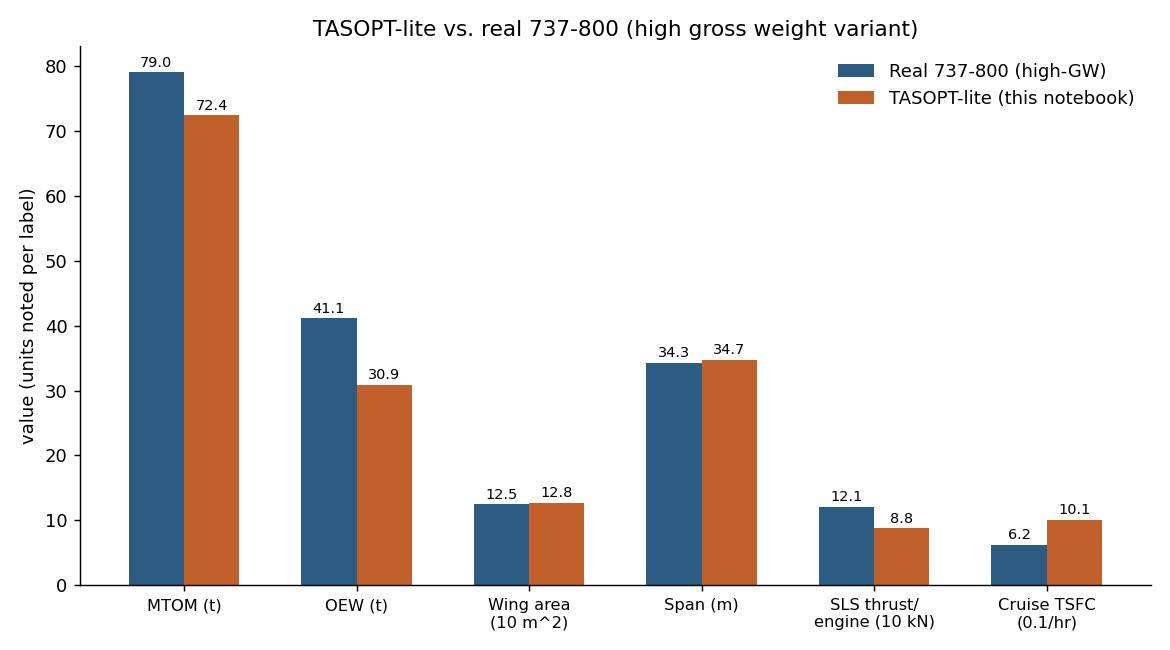

In [10]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

real = dict(MTOM=79015.0, OEW=41145.0, S=125.0, b=34.31, thrust=121.4, TSFC=0.625)
ours = dict(MTOM=res['MTOM'], OEW=res['OEW'], S=res['S'], b=res['b'],
            thrust=res['F_TO_per_eng']/1000.0, TSFC=res['TSFC'])

labels = ['MTOM (t)', 'OEW (t)', 'Wing area\n(10 m^2)', 'Span (m)', 'SLS thrust/\nengine (10 kN)', 'Cruise TSFC\n(0.1/hr)']
real_vals = [real['MTOM']/1000, real['OEW']/1000, real['S']/10, real['b'], real['thrust']/10, real['TSFC']/0.1]
our_vals  = [ours['MTOM']/1000, ours['OEW']/1000, ours['S']/10, ours['b'], ours['thrust']/10, ours['TSFC']/0.1]

x = np.arange(len(labels))
w = 0.32

fig, ax = plt.subplots(figsize=(9, 5), dpi=130)
b1 = ax.bar(x - w/2, real_vals, w, label='Real 737-800 (high-GW)', color='#2C5C82')
b2 = ax.bar(x + w/2, our_vals,  w, label='TASOPT-lite (this notebook)', color='#C1602A')

for bars in (b1, b2):
    for rect in bars:
        h = rect.get_height()
        ax.annotate(f'{h:.1f}', (rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('value (units noted per label)')
ax.set_title('TASOPT-lite vs. real 737-800 (high gross weight variant)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('comparison_chart.png', dpi=130)
plt.show()

print("\nPercent differences (notebook vs. real):")
for k in ['MTOM', 'OEW', 'S', 'b', 'thrust', 'TSFC']:
    pct = 100.0 * (ours[k] - real[k]) / real[k]
    print(f"  {k:8s}: {pct:+6.1f}%")

## 11. Limitations, and where to go for the real thing

This notebook is deliberately small enough to read end to end in one
sitting. Everything it gets right, it gets right because the underlying
physics (pressure-vessel hoop stress, cantilever bending, Brayton-cycle
thermodynamics, the Breguet range equation) doesn't care how you
implement it. Everything it gets wrong, it gets wrong in the places real
TASOPT spends the most code: the transonic airfoil drag database, the
spanwise structural integral, the off-design engine maps, and the
segment-by-segment mission integration.

If you want the real thing:

- **The technical description**: Mark Drela, *TASOPT 2.00: Transport
  Aircraft System OPTimization, Technical Description*, MIT, 2010 — the
  PDF this notebook and its companion article are both built from.
- **The code**: [MIT-LAE/TASOPT.jl](https://github.com/MIT-LAE/TASOPT.jl),
  the maintained open-source Julia implementation, with the full
  structural, aerodynamic and propulsion sub-models this notebook only
  sketches.
- **The companion article**: [Weight, Drag, Thrust, Range](https://claude.ai/code/artifact/d4bac5f7-de63-4425-98d8-02f3943b250f) —
  the prose and interactive-widget explanation of *why* each equation in
  this notebook looks the way it does.

Try changing `geom.AR`, `eng.BPR`, or `mission.range_target_km` above and
re-running Sections 9-10 — that's the actual point of a sizing loop like
this one: not to nail a single airplane, but to see which direction the
whole aircraft moves when one design variable changes.